In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('melb_data.csv')
print(df.shape)

(13580, 21)


In [68]:
# missing values per column
missing_counts = df.isnull().sum()

# precentage of missing values
missing_percentages = (df.isnull().sum() / len(df)) * 100

# Table of missing count and percentage
missing_summary = pd.DataFrame(
    {'Missing Count': missing_counts,
    'Percentage (%)': missing_percentages})

# shows the varibles that has missing values in decending order
final_report = missing_summary[missing_summary['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print(final_report)

              Missing Count  Percentage (%)
BuildingArea           6450       47.496318
YearBuilt              5375       39.580265
CouncilArea            1369       10.081001
Car                      62        0.456554


In [69]:
df['Car'] = df['Car'].fillna(0)

# remove duplicated rows
df.drop_duplicates()

# Fix the Date data type mismatch so it plots chronologically
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')

In [70]:
print("Check")
print("Number of properties with 0 Landsize left:", (df['Landsize'] == 0).sum())
print("Number of properties with 0 Building area left:", (df['BuildingArea'] == 0).sum())
print("Number of missing values left in Car column:", df['Car'].isnull().sum())
print("Total rows remaining in cleaned dataset:", len(df))

Check
Number of properties with 0 Landsize left: 1939
Number of properties with 0 Building area left: 17
Number of missing values left in Car column: 0
Total rows remaining in cleaned dataset: 13580


Text(0.5, 1.0, 'Correlation Matrix of Housing Variables')

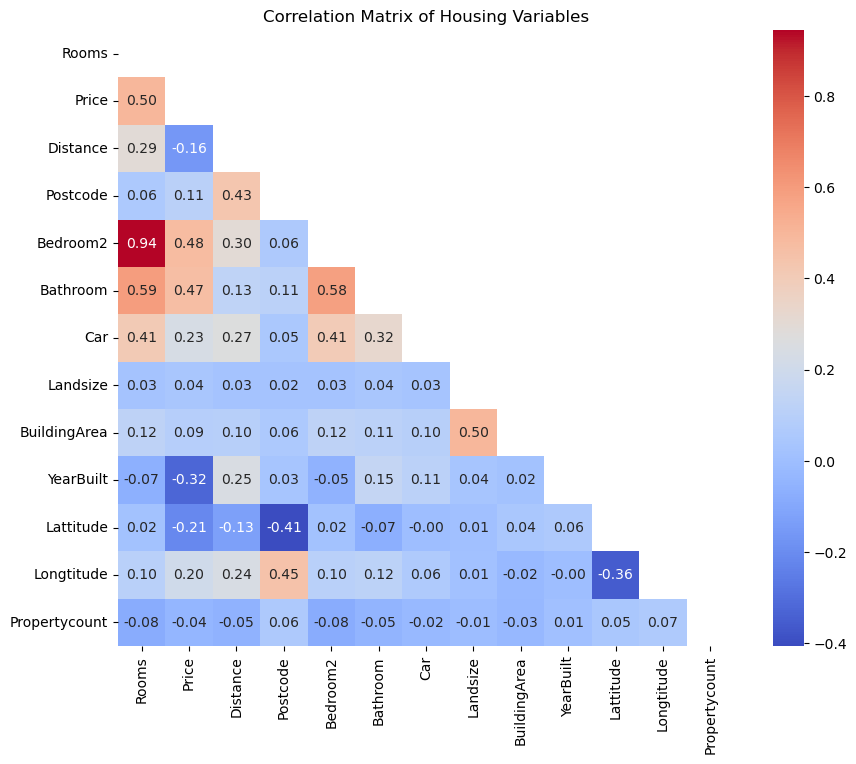

In [71]:
corr = df.corr(numeric_only=True)

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))

# Pass the mask into the heatmap function
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", square=True)

plt.title("Correlation Matrix of Housing Variables")

In [75]:
# remove columns that we do not need
df = df.drop(
    columns=[
        "BuildingArea",
        "SellerG",
        "Date",
        "Postcode",
        "Address",
        "Propertycount",
    ],
    errors="ignore",
)

# creates new features for analysing
df = df.assign(
    Price_per_Landsize = lambda x: x['Price'] / x['Landsize'],
    Distance_Category = pd.cut(
        df['Distance'],
        bins=[0, 10, 20, 30, float('inf')],
        labels=['Near', 'Middle', 'Far', 'Outer']
    )
)

In [76]:
# Clean Landsize
Q1_land = df["Landsize"].quantile(0.25)
Q3_land = df["Landsize"].quantile(0.75)
IQR_land = Q3_land - Q1_land
lower_land = Q1_land - 1.5 * IQR_land
upper_land = Q3_land + 1.5 * IQR_land
df = df[(df["Landsize"] >= lower_land) & (df["Landsize"] <= upper_land)]

# Clean YearBuilt
Q1_year = df["YearBuilt"].quantile(0.25)
Q3_year = df["YearBuilt"].quantile(0.75)
IQR_year = Q3_year - Q1_year
lower_year = Q1_year - 1.5 * IQR_year
upper_year = Q3_year + 1.5 * IQR_year
df = df[(df["YearBuilt"] >= lower_year) & (df["YearBuilt"] <= upper_year)]

# Clean Price
Q1_price = df["Price"].quantile(0.25)
Q3_price = df["Price"].quantile(0.75)
IQR_price = Q3_price - Q1_price
lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price
df = df[(df["Price"] >= lower_price) & (df["Price"] <= upper_price)]

print("Total rows remaining:", len(df))

Total rows remaining: 7609


Text(0.5, 1.0, 'Correlation Matrix of Housing Variables')

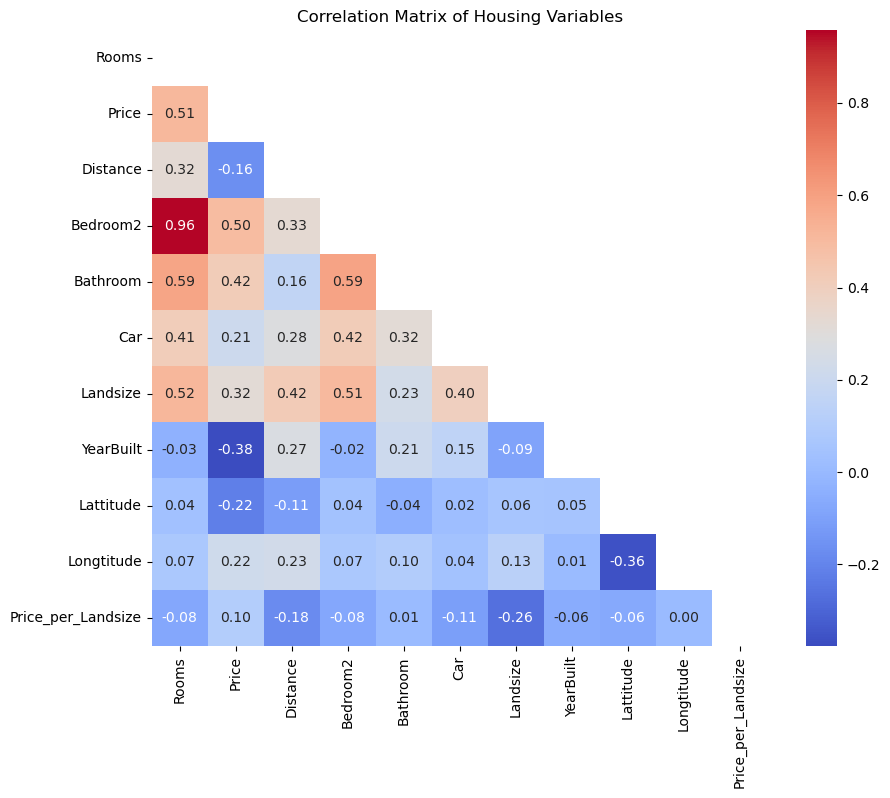

In [77]:
corr = df.corr(numeric_only=True)

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))

# Pass the mask into the heatmap function
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", square=True)

plt.title("Correlation Matrix of Housing Variables")

In [65]:
df.to_csv('cleaned_melb_dataset.csv', index = False)
print('data cleaned successfully!')

data cleaned successfully!
